<a href="https://colab.research.google.com/github/Keerthana177-stack/Keerthana177-stack/blob/main/Hotel_Booking_Cancellation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
df=pd.read_csv('/content/hotel_bookings.csv')
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
df['children'].fillna(df['children'].median(), inplace=True)

df['country'].fillna(df['country'].mode()[0], inplace=True)

df['agent'].fillna(0, inplace=True)

/tmp/ipykernel_1022/1806243773.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['children'].fillna(df['children'].median(), inplace=True)
/tmp/ipykernel_1022/1806243773.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

In [ ]:
df['company'].isnull().sum()

np.int64(112593)

In [ ]:
missing_percent = (df['company'].isnull().sum() / len(df)) * 100
print(missing_percent)

94.30689337465449


In [ ]:
df.drop('company', axis=1, inplace=True)

<Axes: xlabel='is_canceled', ylabel='count'>

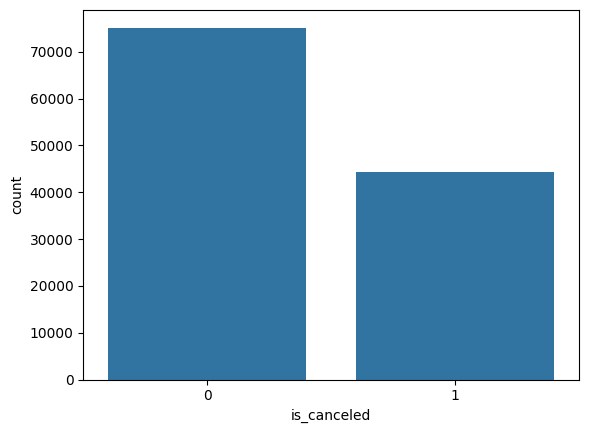

In [ ]:
# Exploratory Data Analysis (EDA)
#  Cancellation Distribution
sns.countplot(x='is_canceled', data=df)

<Axes: xlabel='hotel', ylabel='count'>

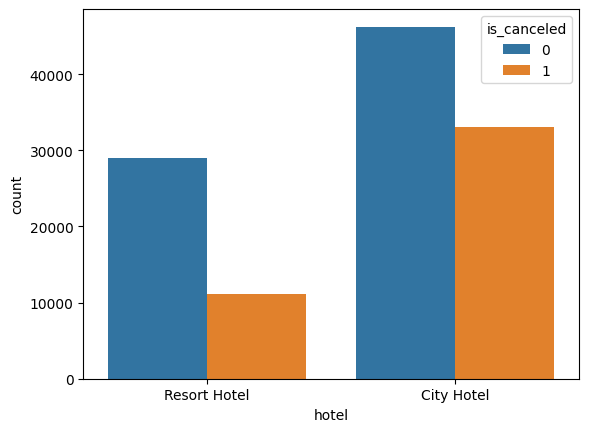

In [ ]:
# Hotel Type vs Cancellation
sns.countplot(x='hotel',
              hue='is_canceled',
              data=df)

<Axes: xlabel='is_canceled', ylabel='lead_time'>

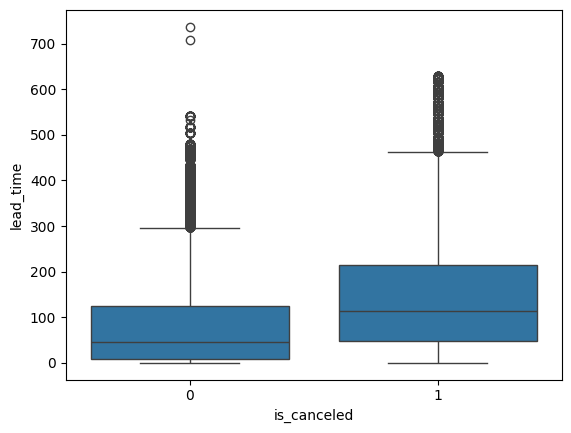

In [ ]:
# Lead Time Analysis
sns.boxplot(x='is_canceled',
            y='lead_time',
            data=df)

In [ ]:
# Calculate IQR
Q1 = df['lead_time'].quantile(0.25)
Q3 = df['lead_time'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-195.0 373.0


In [ ]:
# Check Number of Outliers
outliers = df[(df['lead_time'] < lower_bound) |
              (df['lead_time'] > upper_bound)]

print("Number of outliers:", len(outliers))

Number of outliers: 3005


In [ ]:
# Remove Outliers
df = df[(df['lead_time'] >= lower_bound) &
        (df['lead_time'] <= upper_bound)]

In [ ]:
print(df.shape)

(116385, 31)


In [ ]:
# Cap Outliers
df['lead_time'] = np.where(
    df['lead_time'] > upper_bound,
    upper_bound,
    df['lead_time']
)

df['lead_time'] = np.where(
    df['lead_time'] < lower_bound,
    lower_bound,
    df['lead_time']
)

/tmp/ipykernel_1022/2935674821.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lead_time'] = np.where(
/tmp/ipykernel_1022/2935674821.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lead_time'] = np.where(


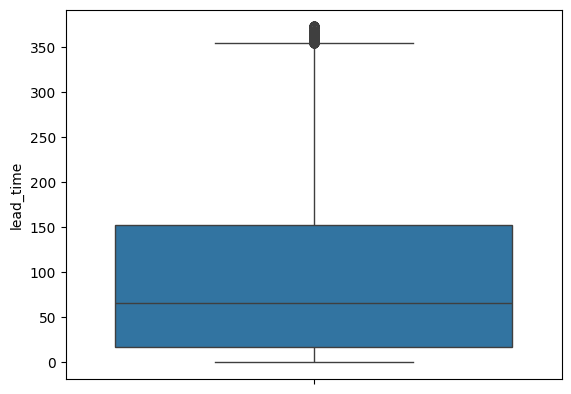

In [ ]:
 # Boxplot after capping outliers
sns.boxplot(y=df['lead_time'])
plt.show()

<Axes: xlabel='deposit_type', ylabel='count'>

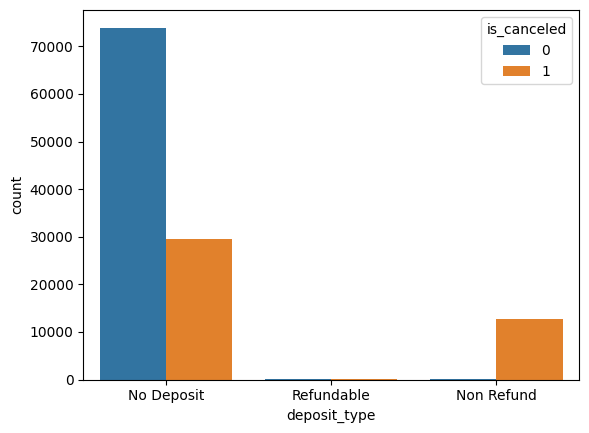

In [ ]:
# Deposit Type Analysis
sns.countplot(x='deposit_type',
              hue='is_canceled',
              data=df)

<Axes: >

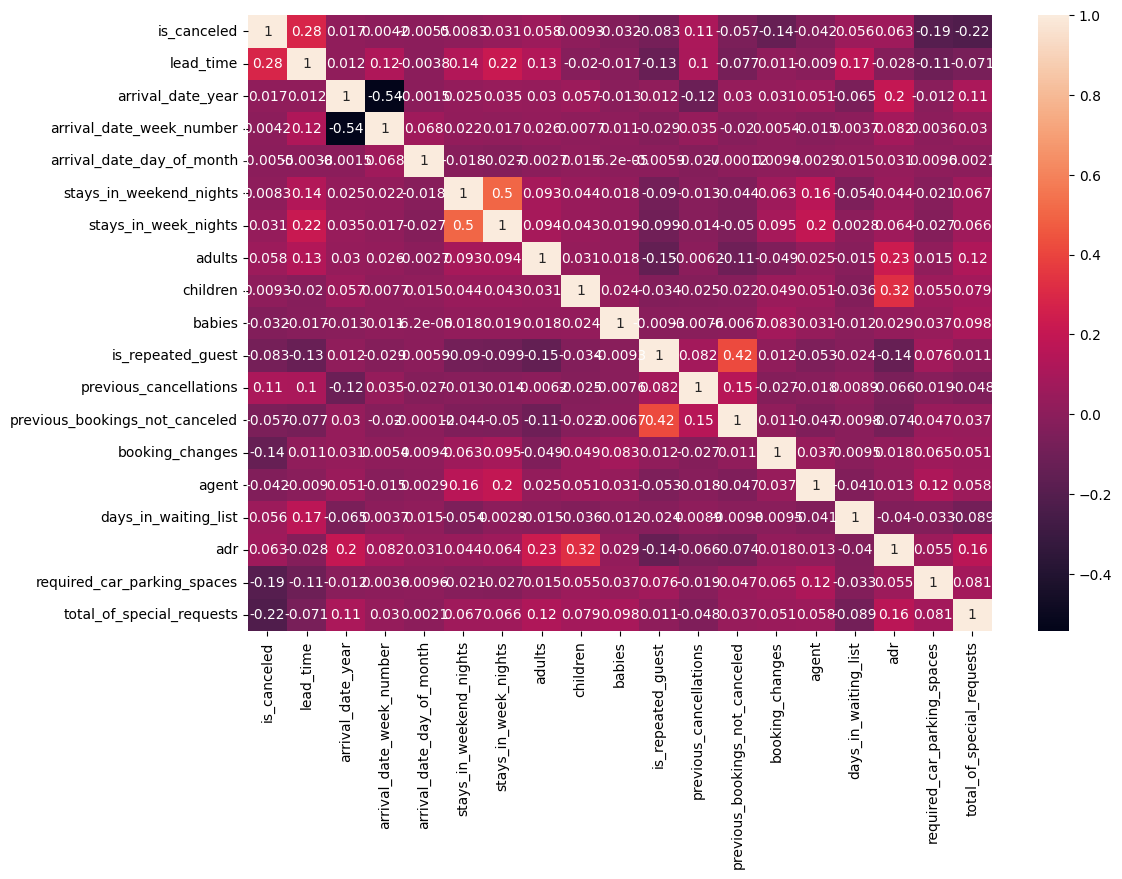

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [ ]:
# Total Stay Nights
df['total_stay'] = (
    df['stays_in_week_nights']
    + df['stays_in_weekend_nights']
)

/tmp/ipykernel_1022/3802357819.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['total_stay'] = (


In [ ]:
# Family Size
df['family_size'] = (
    df['adults']
    + df['children']
    + df['babies']
)

/tmp/ipykernel_1022/1630474442.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['family_size'] = (


In [ ]:
# Season Extraction
def season(month):
    if month in ['December','January','February']:
        return 'Winter'
    elif month in ['March','April','May']:
        return 'Summer'
    elif month in ['June','July','August']:
        return 'Monsoon'
    else:
        return 'Autumn'

df['season'] = df['arrival_date_month'].apply(season)

/tmp/ipykernel_1022/2278160230.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['season'] = df['arrival_date_month'].apply(season)


In [ ]:
# Encoding
# Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['hotel'] = le.fit_transform(df['hotel'])

/tmp/ipykernel_1022/421744309.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hotel'] = le.fit_transform(df['hotel'])


In [ ]:
# One-Hot Encoding
df = pd.get_dummies(df,drop_first=True)

In [ ]:
# Train-Test Split
features = [
    'lead_time',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'booking_changes',
    'adr',
    'total_stay'
]

X = df[features]
y = df['is_canceled']

In [ ]:
# Machine Learning Models
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
# XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)

In [ ]:
y_pred=xgb.predict(X_test)

In [ ]:
y_pred

array([0, 0, 1, ..., 0, 0, 0])

In [ ]:
# Accuracy
accuracy_score(y_test,y_pred)

0.7604931907032694

In [ ]:
# Precision
precision_score(y_test,y_pred)

0.7785336356764928

In [ ]:
# Recall
recall_score(y_test,y_pred)

0.48339786460166606

In [ ]:
# F1 Score
f1_score(y_test,y_pred)

0.5964531306550851

<Axes: >

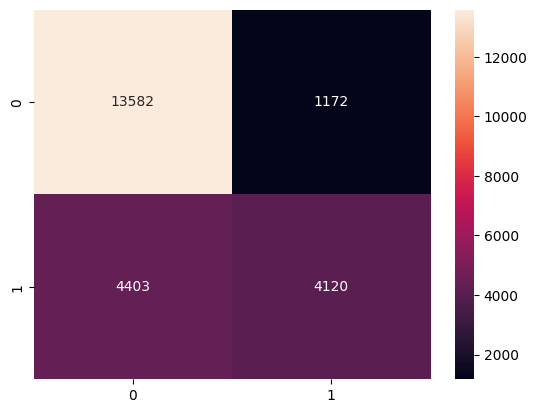

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
params = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15]
}

In [ ]:
rf= RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
import joblib

joblib.dump(rf, "hotel_model.pkl")

['hotel_model.pkl']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
from google.colab import files

files.download("hotel_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>